#### El experimento escogido es: /home/slozgom/personal/tfg_project/xperiments/experimentos_con_cnn/05_iid_complete

In [1]:
from typing import Iterable
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Let's try plots with 5 agents
NON_COMPLETE = Path("./xperiments/experimentos_con_cnn/05_non_complete/raw/")
NON_RING = Path("./xperiments/experimentos_con_cnn/05_non_ring/raw/")
NON_SW = Path("./xperiments/experimentos_con_cnn/05_non_sw/raw/")
PATHS = [NON_COMPLETE, NON_RING, NON_SW]
NAMES = ["NON_COMPLETE", "NON_RING", "NON_SW"]
COLORS = ["blue", "red", "green"]
SUBPLOT = 221
print("*DATASETS*")
for file in NON_COMPLETE.iterdir():
    print(file.name)


*DATASETS*
nn_train.csv
general.log
data_split.csv
nn_convergence.csv
nn_inference.csv
message.csv
algorithm.csv


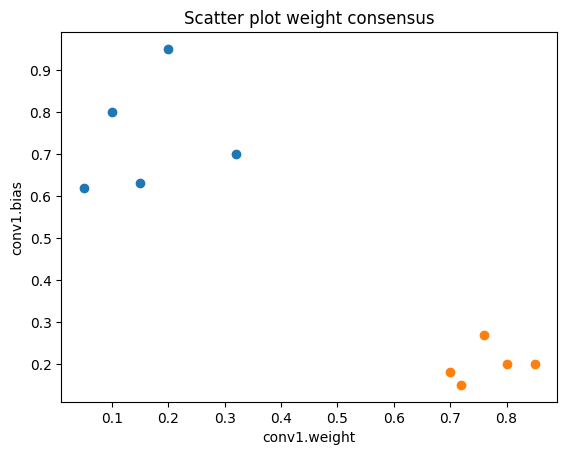

In [13]:
plt.figure()
plt.title("Scatter plot weight consensus")
plt.xlabel("conv1.weight")
plt.ylabel("conv1.bias")
plt.scatter([0.05,0.1,0.2,0.15,0.32], [0.62,0.8,0.95,0.63,0.7])
plt.scatter([0.72,0.8,0.85,0.7,0.76], [0.15,0.2,0.2,0.18,0.27])
plt.show()

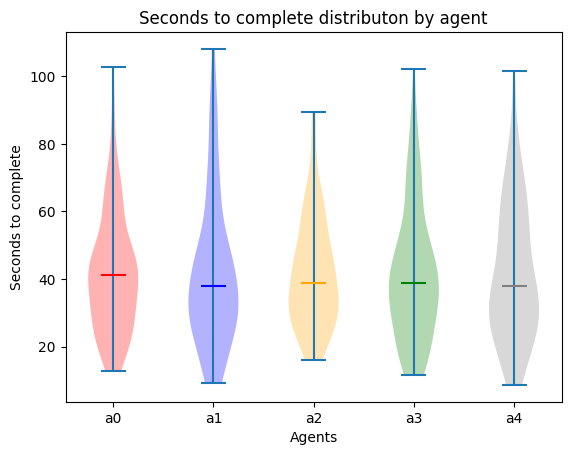

In [5]:
data = pd.read_csv(NON_COMPLETE / "algorithm.csv")
agents = ["a0", "a1", "a2", "a3", "a4"]
colors = ["red", "blue", "orange", "green", "grey"]
times = []
for agent in agents:
    agent_data = data[(data.agent==agent+"@localhost")]
    time = list(agent_data.seconds_to_complete)
    times.append(time)
    
plt.figure()
plt.title("Seconds to complete distributon by agent")
plt.xlabel("Agents")
plt.ylabel("Seconds to complete")
violin_parts = plt.violinplot(times, showmedians=True)
for pc,color in zip(violin_parts['bodies'], colors):
    pc.set_facecolor(color)
#violin_parts['cmeans'].set_color(colors)
violin_parts['cmedians'].set_color(colors)
plt.xticks(list(range(1,6)), agents)
plt.show()

In [ ]:
import plotly.express as px
df = px.data.gapminder()
px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
    size="pop", color="continent", hover_name="country",
    log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

In [23]:
data = pd.read_csv(NON_COMPLETE / "nn_convergence.csv")
agents = data.agent.unique()
post_data = data[(data.description.isin(["POST-TRAIN", "POST-CONSENSUS"]))]
for agent in agents:
    print(len(post_data[(post_data.agent==agent)])/8)

892.0
872.0
914.0
911.0
913.0


In [22]:
post_data.to_csv("post_data.csv")

In [ ]:
data = pd.read_csv(NON_COMPLETE / "nn_convergence.csv")
agents = data.agent.unique()
rounds = data.algorithm_round.unique()
epochs = data.epoch_or_iteration.unique()
layers = data.layer.unique()

df = pd.DataFrame(columns=["agent", "description", "algorithm_round"])
POST = "POST"
for round in rounds:
    for epoch in epochs:
        agents_data = data[(data.algorithm_round==round) & (data.epoch_or_iteration==epoch)]
        layer_variances = []
        for description in agents_data.description.unique():
            if POST in description:
                desc_data = agents_data[(agents_data.description==description)]
                for layer in desc_data.layer.unique():
                    layer_data = desc_data[(desc_data.layer == layer)]
                    print(layer_data)
                    print("@@@")
                    #weights_variance = np.var(layer_data.weight)
                    #layer_variances.append(weights_variance)

Con el Convergence value over the time esperamos que al menos al final las difierencias entre agentes (convergence value) sean mínimas.

Cogemos el valor PRE_TRAIN en la época 1, es decir(justo después de las iteraciones de convergencia)

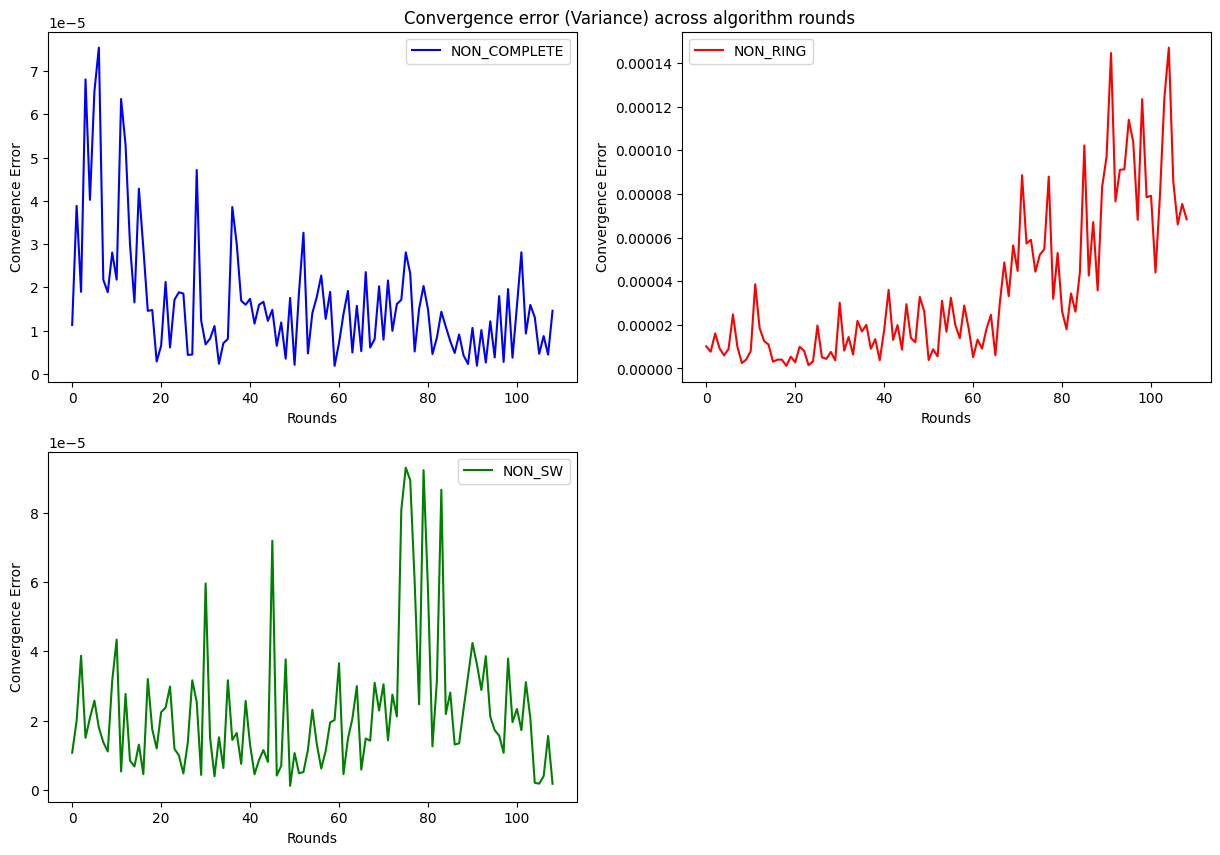

In [2]:
# Usando varianza, con los valores inmediatamente después del consenso

convergence_errors = []
for path in PATHS:
    data = pd.read_csv(path / "nn_convergence.csv")
    agents = data.agent.unique()
    rounds = data.algorithm_round.unique()
    epochs = data.epoch_or_iteration.unique()
    layers = data.layer.unique()

    alg_variances = []
    description = "PRE-TRAIN"
    epoch = 1
    for round in rounds:
        agents_data = data[(data.algorithm_round==round) & (data.epoch_or_iteration==epoch) & (data.description==description)]
        layer_variances = []
        for layer in agents_data.layer.unique():
            layer_data = agents_data[(agents_data.layer == layer)]
            weights_variance = np.var(layer_data.weight)
            layer_variances.append(weights_variance)
        variance_sum = np.sum(np.array(layer_variances))
        alg_variances.append(variance_sum)
    convergence_errors.append(alg_variances)


plt.figure(figsize=(15,10))
plt.axis('off')
plt.title(f"Convergence error (Variance) across algorithm rounds")
for i, (convergence, path, name, color) in enumerate(zip(convergence_errors, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.plot(convergence[1::], color=color, label=name)
    plt.xlabel("Rounds")
    plt.ylabel("Convergence Error") 
    plt.legend(loc="best")
plt.show()

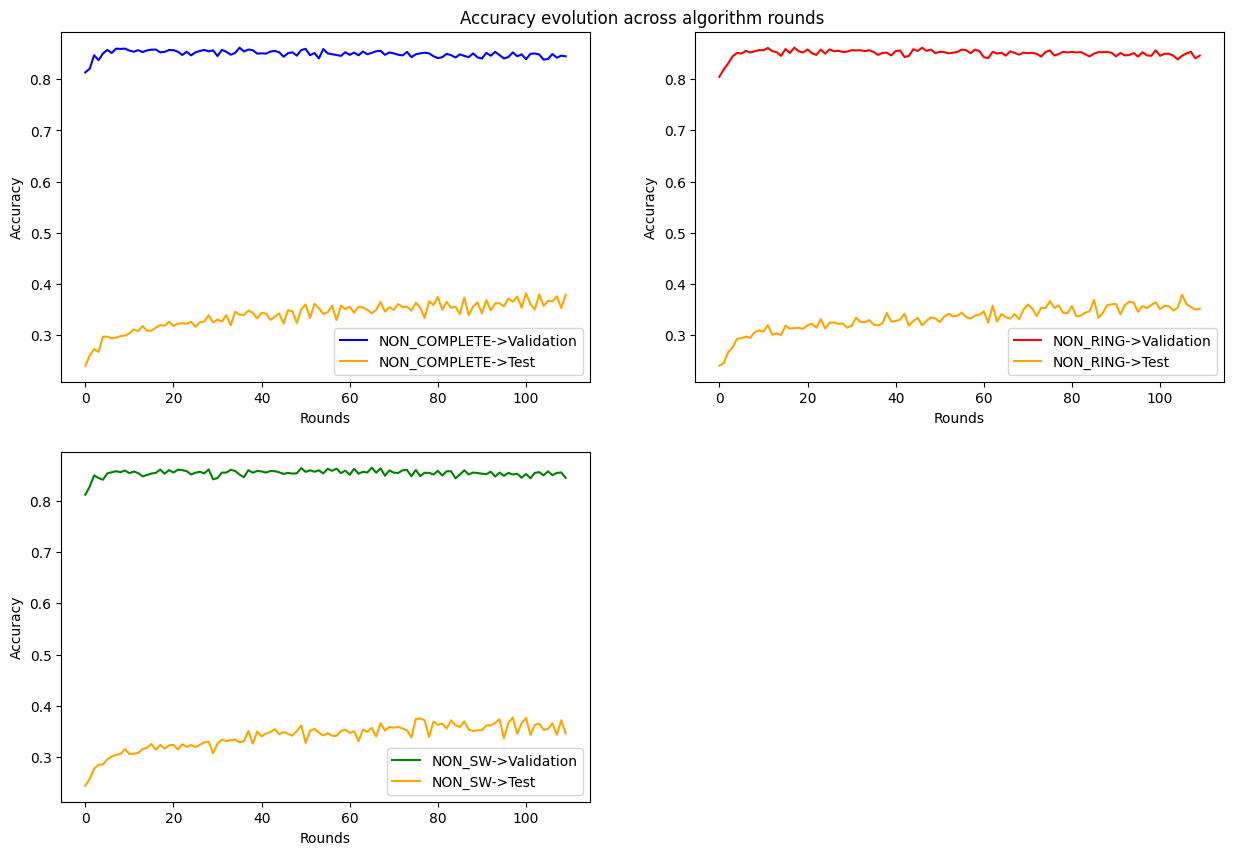

In [31]:
accuracy_values = []
for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "nn_inference.csv")
    test_accuracies = []
    validation_accuracies = []
    for round in rounds:
        inference_data = data[(data.algorithm_round==round)]
        test_accuracy = np.mean(np.array([inference_data.test_accuracy]))
        validation_accuracy = np.mean(np.array([inference_data.validation_accuracy]))
        test_accuracies.append(test_accuracy)
        validation_accuracies.append(validation_accuracy)
    accuracy_values.append([validation_accuracies, test_accuracies])


plt.figure(figsize=(15,10))
plt.axis('off')
plt.title("Accuracy evolution across algorithm rounds")
for i, (accuracies, path, name, color) in enumerate(zip(accuracy_values, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.plot(accuracy_values[i][0], label=f"{name}->Validation", color=color)
    plt.plot(accuracy_values[i][1], label=f"{name}->Test", color="orange")
    plt.xlabel("Rounds")
    plt.ylabel("Accuracy") 
    plt.legend(loc="best")
plt.show()

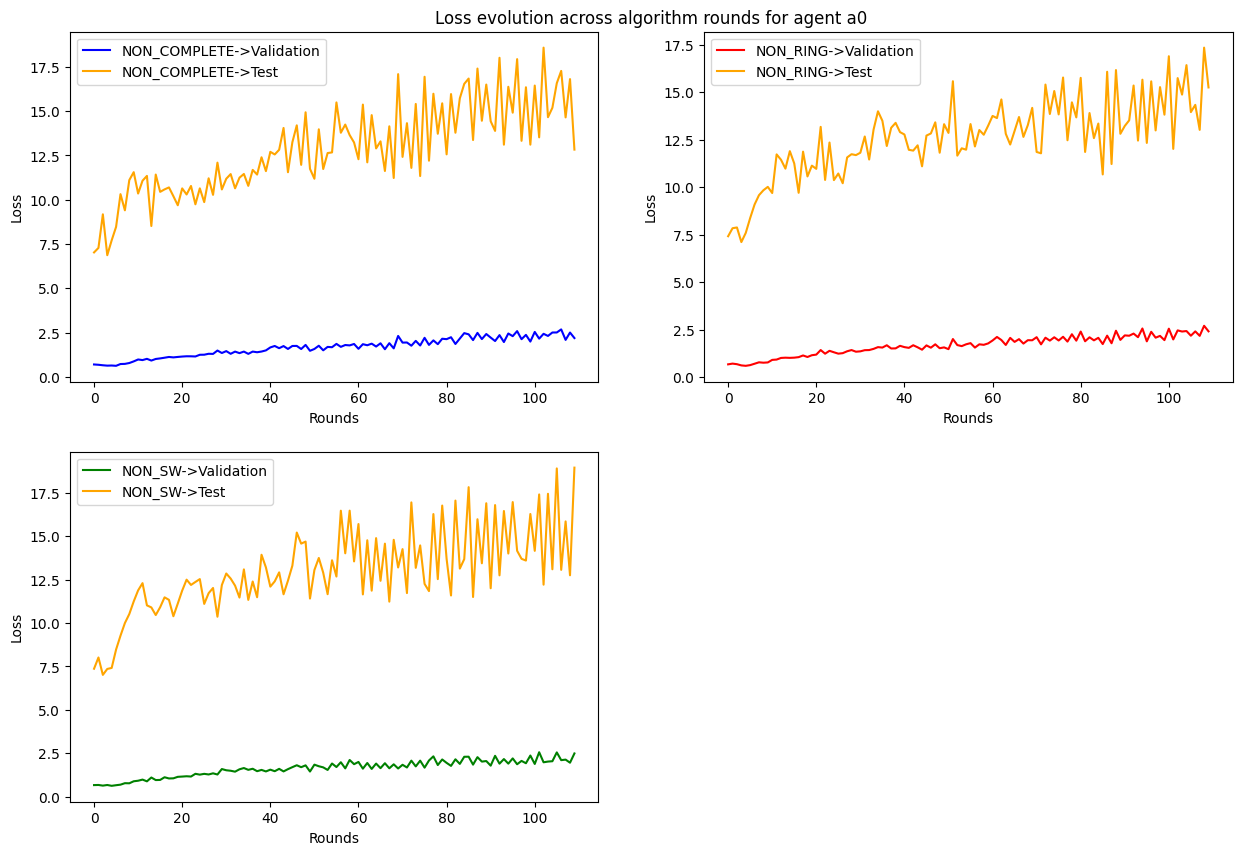

In [4]:
losses_values = []
for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "nn_inference.csv")
    data.algorithm_round.unique()
    test_losses = []
    validation_losses = []
    for round in rounds:
        inference_data = data[(data.algorithm_round==round) & (data.agent=="a0")]
        test_loss = np.mean(np.array([inference_data.test_loss]))
        validation_loss = np.mean(np.array([inference_data.validation_loss]))
        #test_loss = inference_data.test_loss
        #validation_loss = inference_data.validation_loss
        test_losses.append(test_loss)
        validation_losses.append(validation_loss)
    losses_values.append([validation_losses, test_losses])


plt.figure(figsize=(15,10))
plt.axis('off')
plt.title("Loss evolution across algorithm rounds for agent a0")
for i, (accuracies, path, name, color) in enumerate(zip(losses_values, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.plot(losses_values[i][0], label=f"{name}->Validation", color=color)
    plt.plot(losses_values[i][1], label=f"{name}->Test", color="orange")
    plt.xlabel("Rounds")
    plt.ylabel("Loss") 
    plt.legend(loc="best")
plt.show()

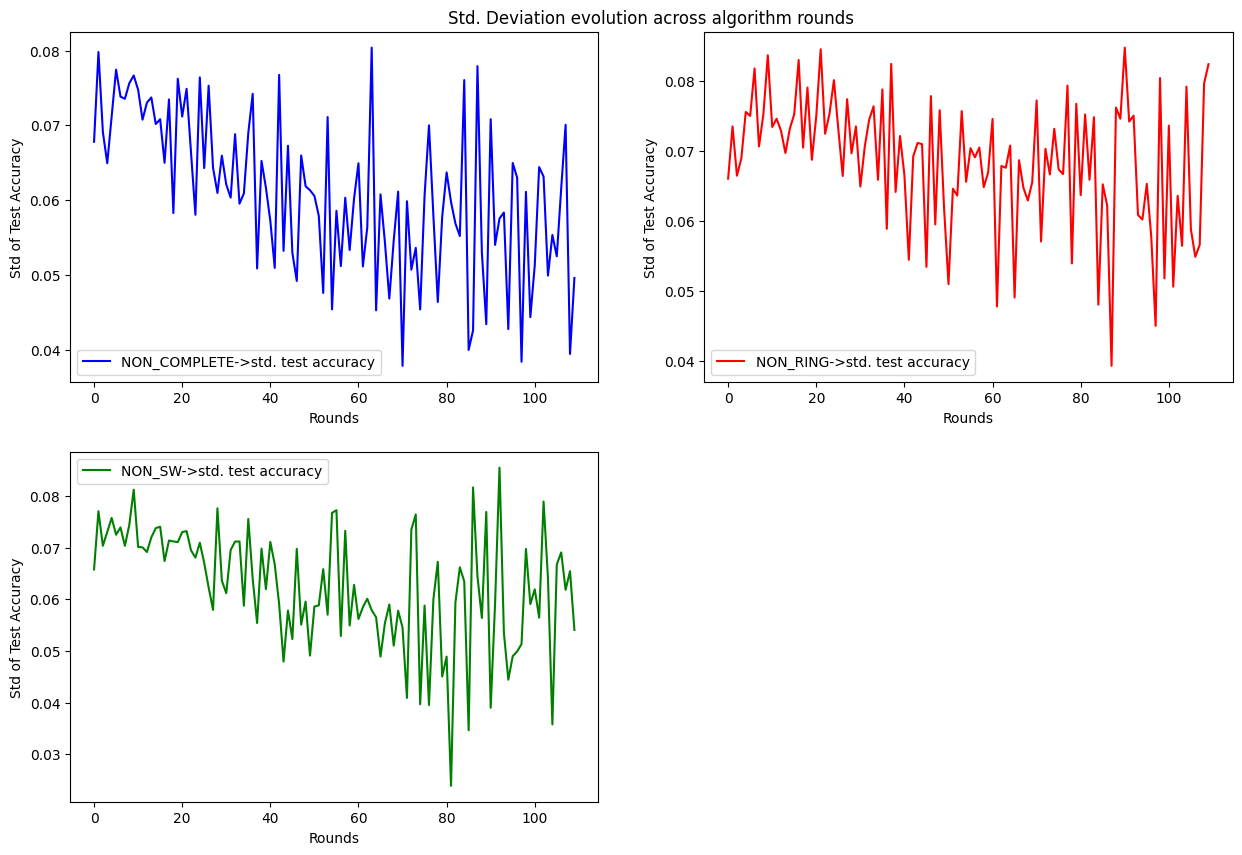

In [32]:
std_deviations = []
for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "nn_inference.csv")
    deviations = []
    for round in rounds:
        inference_data = data[(data.algorithm_round==round)]
        test_accuracy = np.std(np.array([inference_data.test_accuracy]))
        deviations.append(test_accuracy)
    std_deviations.append(deviations)


plt.figure(figsize=(15,10))
plt.axis('off')
plt.title("Std. Deviation evolution across algorithm rounds")
for i, (deviations, path, name, color) in enumerate(zip(std_deviations, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.plot(deviations, label=f"{name}->std. test accuracy", color=color)
    plt.xlabel("Rounds")
    plt.ylabel("Std of Test Accuracy") 
    plt.legend(loc="best")
plt.show()

*¿Hay correlación entre el desempeño y la suma de varianzas calculada?

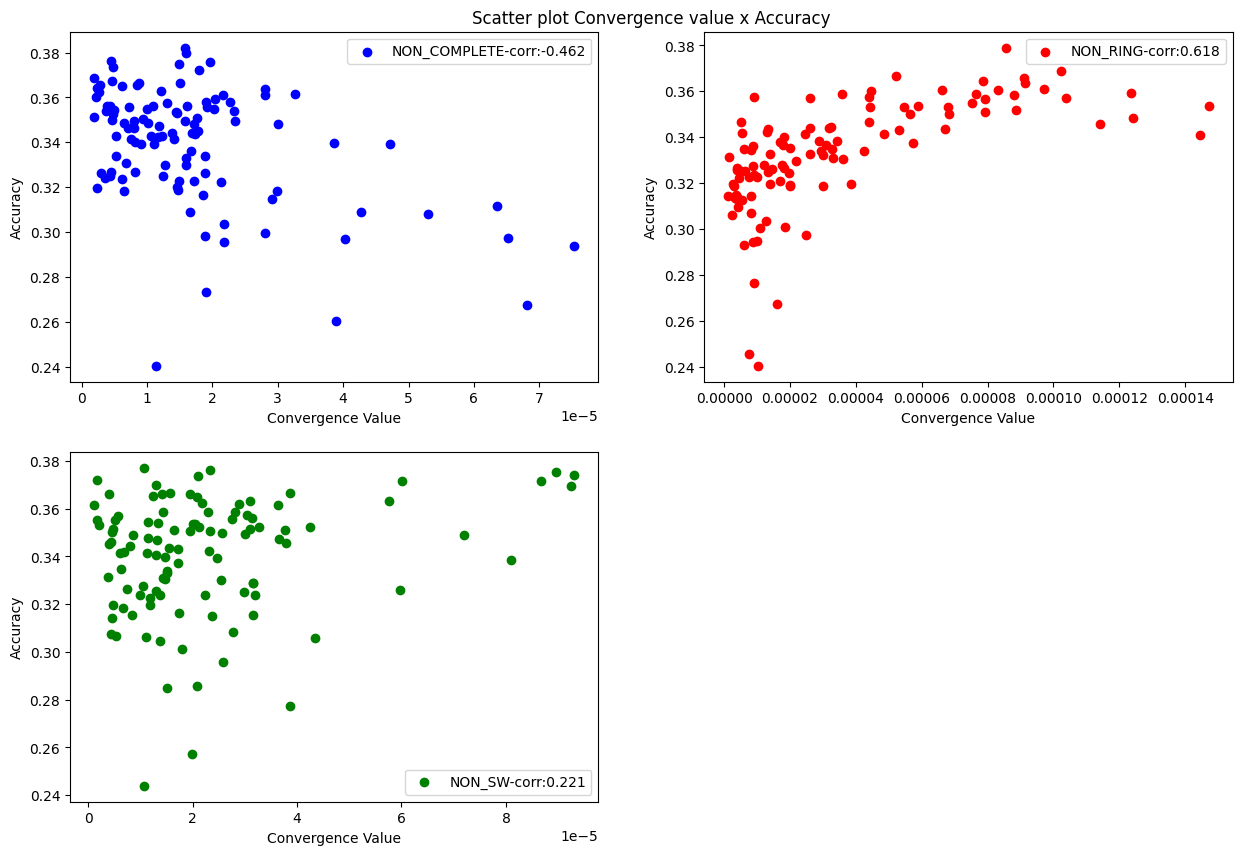

In [33]:
plt.figure(figsize=(15,10))
plt.axis('off')
plt.title("Scatter plot Convergence value x Accuracy")
for i, (convergence, accuracies, path, name, color) in enumerate(zip(convergence_values, accuracy_values, PATHS, NAMES, COLORS)):
    df = pd.DataFrame({"vars": convergence[1:], "accs": accuracies[1][:-1]})
    corr = df.corr(method="pearson").values[0,1]
    corr = "{:.3f}".format(corr)
    plt.subplot(SUBPLOT+i)
    plt.scatter(convergence[1:], accuracies[1][:-1], label=f"{name}-corr:{corr}", color=color)
    plt.xlabel("Convergence Value")
    plt.ylabel("Accuracy") 
    plt.legend(loc="best")
plt.show()


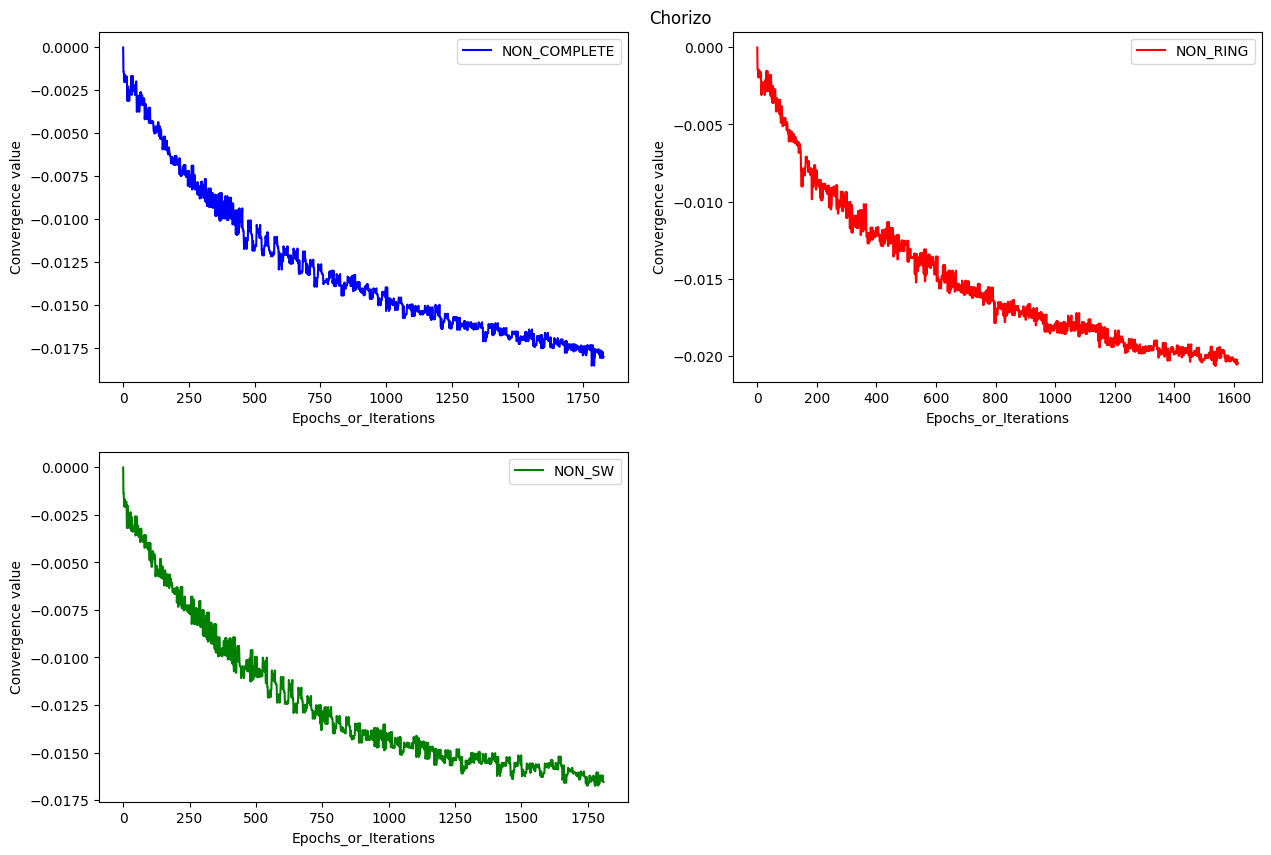

In [38]:
import warnings
warnings.filterwarnings('ignore')

chorizos = []
for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "nn_convergence.csv")
    times = data.description.unique()
    accuracies = []
    data = data[(data.agent=="a2")]
    for round in rounds:
        for epoch in epochs:
            inference_data = data[(data.algorithm_round==round) & (data.epoch_or_iteration==epoch)]
            epoch_weight = inference_data[(data.layer=="fc1.weight")]
            for i in epoch_weight.weight:
                accuracies.append(i)
    chorizos.append(accuracies)

plt.figure(figsize=(15,10))            
plt.title("Chorizo")
plt.axis('off')
for i, (chorizo, path, name, color) in enumerate(zip(chorizos, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.plot(chorizo, label=name, color=color)
    plt.xlabel("Epochs_or_Iterations")
    plt.ylabel("Convergence value")
    plt.legend(loc="best")
plt.show()

### El problema a continuación es: Asumimos convergencia, pero ¿en qué punto podemos decir que hay un nivel de convergencia suficientemente alto como par decir que han convergido los agentes?

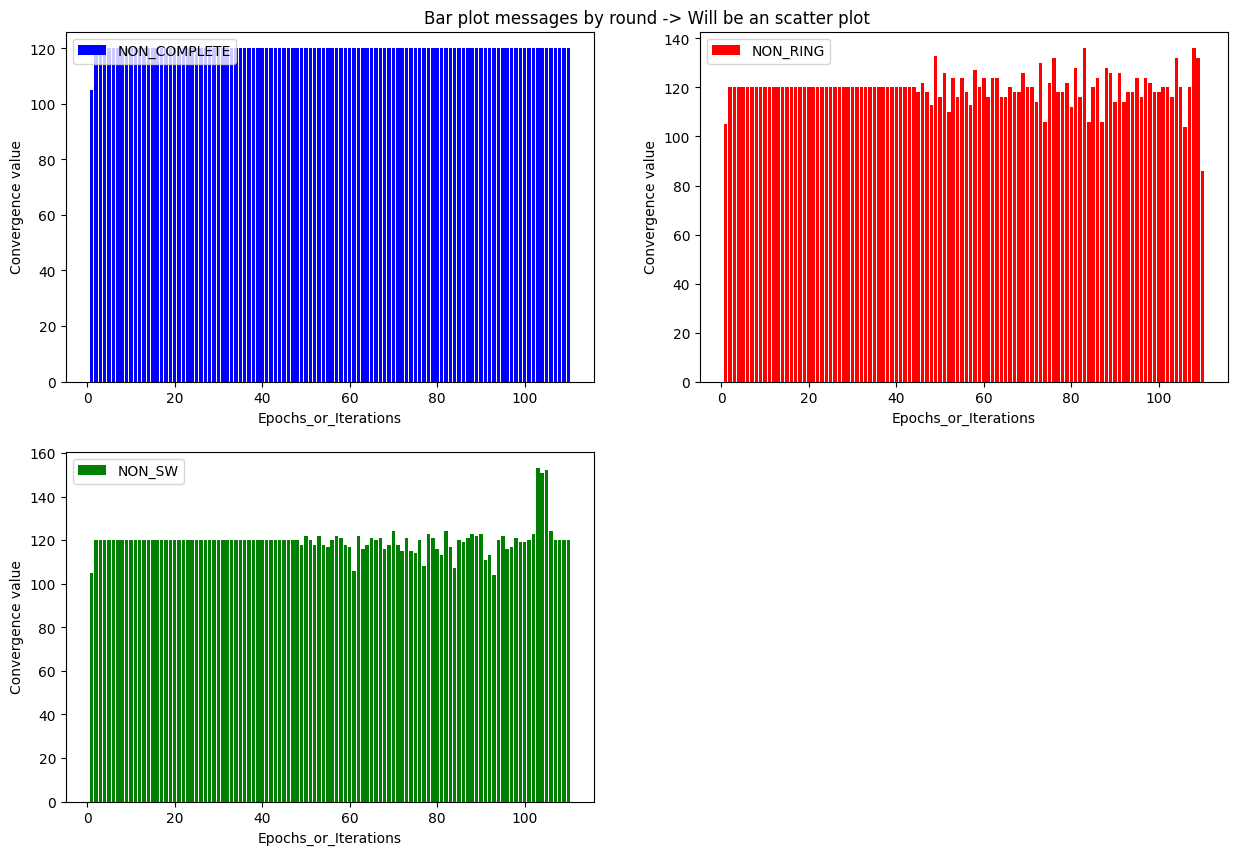

In [14]:
list_messages = []
for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "message.csv")
    rounds = data.algorithm_round.unique()
    messages = []
    for round in rounds:
        message_data = data[(data.algorithm_round==round)]
        messages.append(len(message_data))
    list_messages.append(messages)

plt.figure(figsize=(15,10))            
plt.title("Bar plot messages by round -> Will be an scatter plot")
plt.axis('off')
for i, (messages, path, name, color) in enumerate(zip(list_messages, PATHS, NAMES, COLORS)):
    plt.subplot(SUBPLOT+i)
    plt.bar(rounds, messages, label=name, color=color)
    plt.xlabel("Epochs_or_Iterations")
    plt.ylabel("Convergence value")
    plt.legend(loc="best")
plt.show()

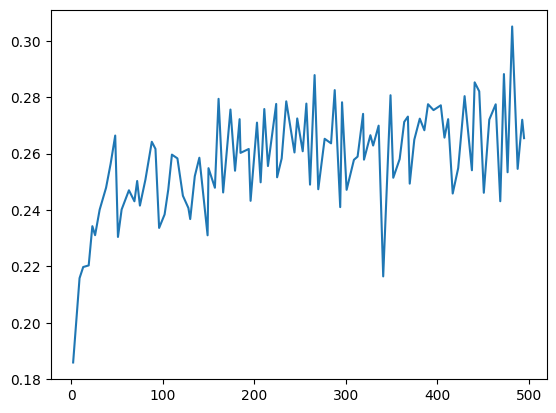

In [34]:
data = pd.read_csv(path / "nn_inference.csv")
agents = data.agent.unique()
a = data[(data.agent=="a2") & (data.algorithm_round<=100)].test_f1_score
plt.plot(a)


### Falta vincular el tamaño al porcentaje de muestras y hacerlo bonito

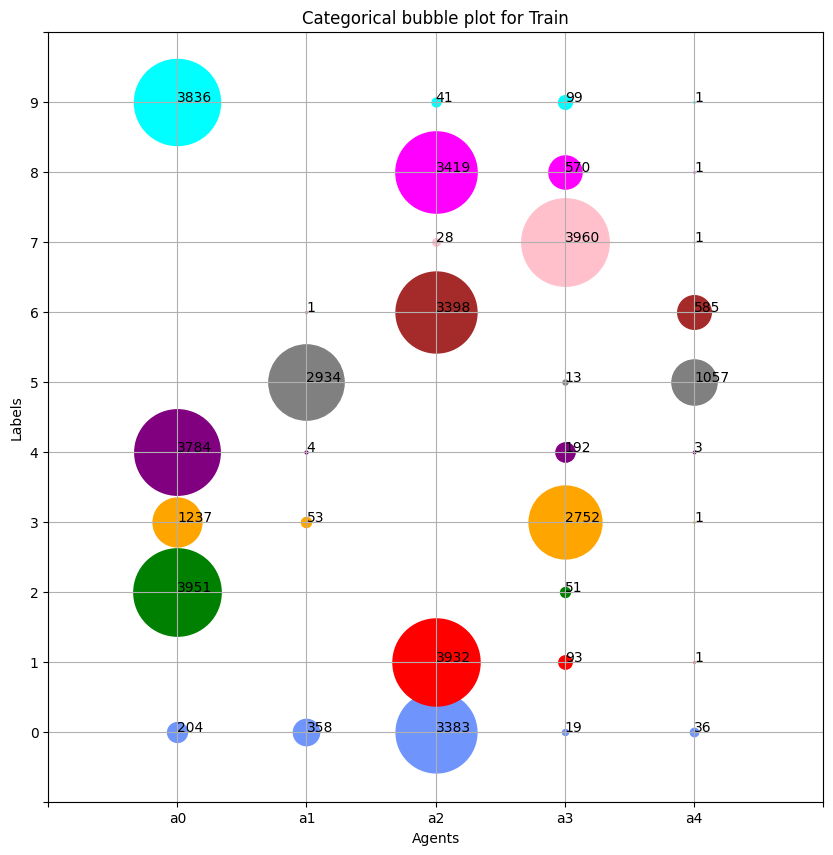

In [ ]:
import numpy as np
colors = ["white", "#6f95fc","red","green", "orange","purple","grey","brown","pink","magenta","cyan", "white"]
data = pd.read_csv(path / "data_split.csv")
agents = data.agent.unique()
phase = "train"
labels = data.label.unique()
X = np.zeros((len(labels)+2, len(agents)+2))
for i, agent in enumerate(agents):
    split_data = data[(data.agent==agent) & (data.description==phase)]
    for x, (_,row) in enumerate(split_data.iterrows()):
        X[row.label+1, i+1] = row["count"]
    
plt.figure(figsize=(10,10))            
plt.title("Categorical bubble plot for Train")
M, N = X.shape
for i in range(M):
    color = colors[i]
    for j in range(N):
        if X[i,j] != 0:
            plt.scatter(j,i, s=X[i,j], color=color)
            plt.text(j, i, f'{int(X[i,j])}')
plt.xlabel("Agents")
plt.ylabel("Labels") 
xticks = [""] + list(agents) + [""]
yticks = [""] + list(sorted(labels)) + [""]
plt.xticks(list(range(N)), xticks)
plt.yticks(list(range(M)), yticks)
plt.grid()
plt.show()

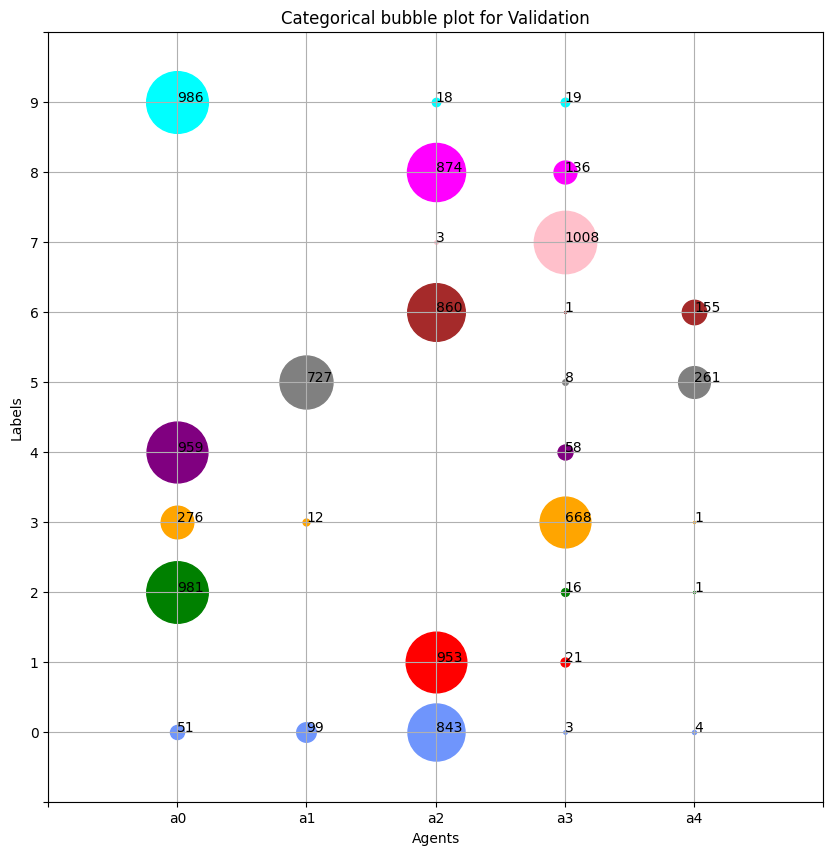

In [5]:
import numpy as np
colors = ["white", "#6f95fc","red","green", "orange","purple","grey","brown","pink","magenta","cyan", "white"]
data = pd.read_csv(path / "data_split.csv")
agents = data.agent.unique()
phase = "validation"
labels = data.label.unique()
X = np.zeros((len(labels)+2, len(agents)+2))
for i, agent in enumerate(agents):
    split_data = data[(data.agent==agent) & (data.description==phase)]
    for x, (_,row) in enumerate(split_data.iterrows()):
        X[row.label+1, i+1] = row["count"]
    
plt.figure(figsize=(10,10))            
plt.title("Categorical bubble plot for Validation")
M, N = X.shape
for i in range(M):
    color = colors[i]
    for j in range(N):
        if X[i,j] != 0:
            plt.scatter(j,i, s=X[i,j]*2, color=color)
            plt.text(j, i, f'{int(X[i,j])}')
plt.xlabel("Agents")
plt.ylabel("Labels") 
xticks = [""] + list(agents) + [""]
yticks = [""] + list(sorted(labels)) + [""]
plt.xticks(list(range(N)), xticks)
plt.yticks(list(range(M)), yticks)
plt.grid()
plt.show()